In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

columns = [
    "ID",
    "Diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df = pd.read_csv(url, header=None, names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Last 5 rows:


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 569
Number of columns: 32


In [7]:
print(df["Diagnosis"].unique())

['M' 'B']


In [8]:
# summary

X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

print("Number of features:", X.shape[1])

Number of features: 30


In [9]:
# mean, median, standard deviation

statistics = pd.DataFrame({
    "Mean": X.mean(),
    "Median": X.median(),
    "Standard Deviation": X.std(),
    "Minimum": X.min(),
    "Maximum": X.max()
})

statistics

,Mean,Median,Standard Deviation,Minimum,Maximum
radius_mean,14.127292,13.370000,3.524049,6.981000,28.11000
texture_mean,19.289649,18.840000,4.301036,9.710000,39.28000
perimeter_mean,91.969033,86.240000,24.298981,43.790000,188.50000
area_mean,654.889104,551.100000,351.914129,143.500000,2501.00000
smoothness_mean,0.096360,0.095870,0.014064,0.052630,0.16340
compactness_mean,0.104341,0.092630,0.052813,0.019380,0.34540
concavity_mean,0.088799,0.061540,0.079720,0.000000,0.42680
concave_points_mean,0.048919,0.033500,0.038803,0.000000,0.20120
symmetry_mean,0.181162,0.179200,0.027414,0.106000,0.30400
fractal_dimension_mean,0.062798,0.061540,0.007060,0.049960,0.09744


In [10]:
# checking missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [11]:
# checking duplicates

print("Number of duplicate rows:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [12]:
# checking outliers

outlier_counts = {}

for column in X.columns:
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X[
        (X[column] < lower_bound) |
        (X[column] > upper_bound)
    ]

    outlier_counts[column] = len(outliers)

outlier_df = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Number of Outliers"]
)

outlier_df

,Number of Outliers
radius_mean,14
texture_mean,7
perimeter_mean,13
area_mean,25
smoothness_mean,6
compactness_mean,16
concavity_mean,18
concave_points_mean,10
symmetry_mean,15
fractal_dimension_mean,15


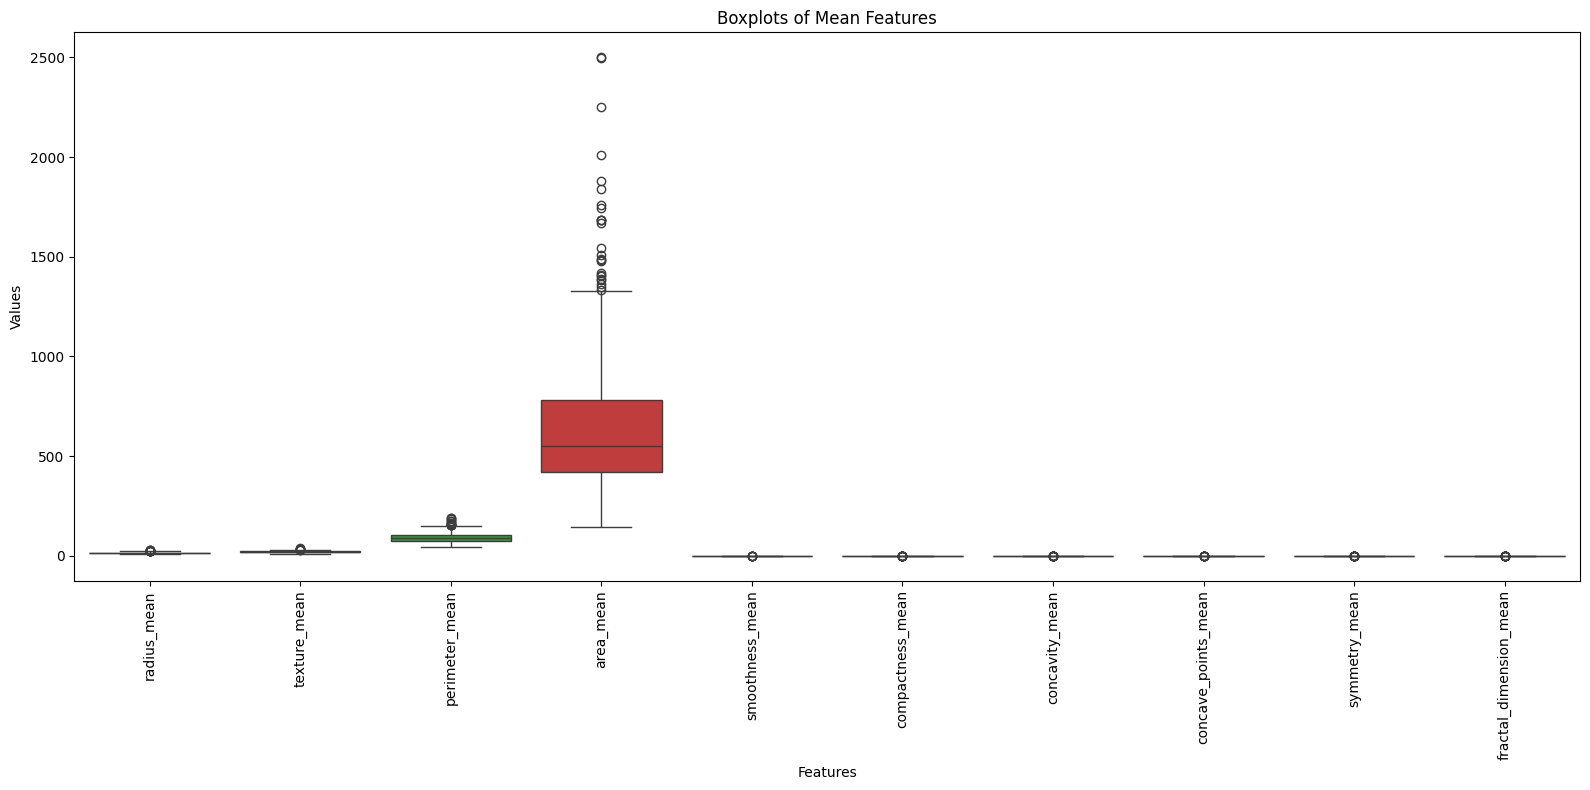

In [13]:
# box plot for outliers

mean_features = [
    col for col in X.columns
    if col.endswith("_mean")
]

plt.figure(figsize=(16, 8))

sns.boxplot(data=X[mean_features])

plt.xticks(rotation=90)
plt.title("Boxplots of Mean Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

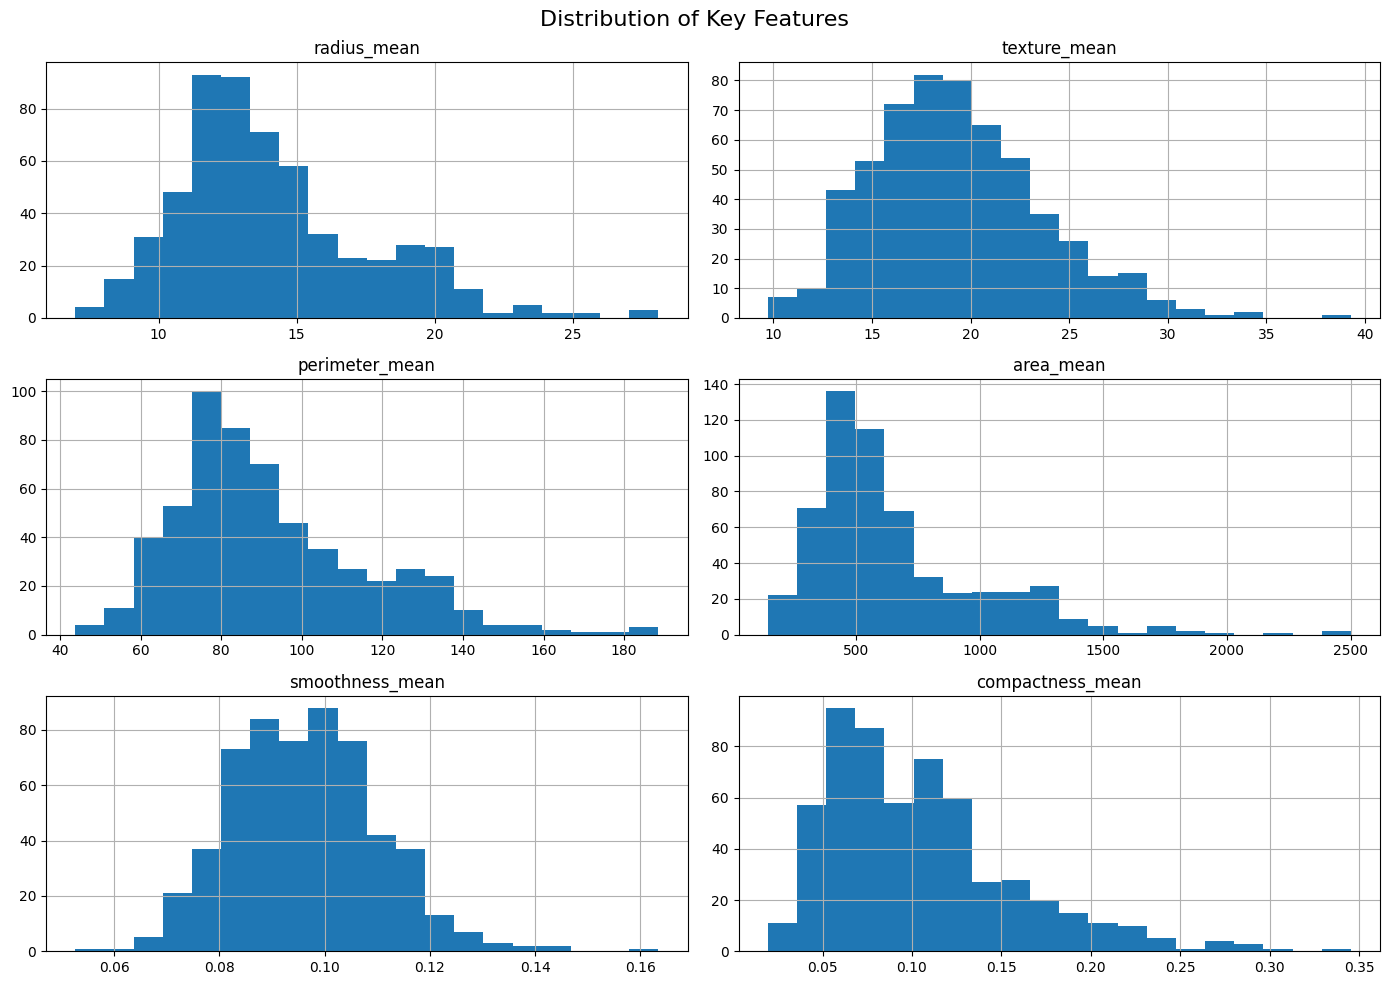

In [14]:
# histogram of imp features

key_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean"
]

X[key_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Key Features", fontsize=16)
plt.tight_layout()
plt.show()

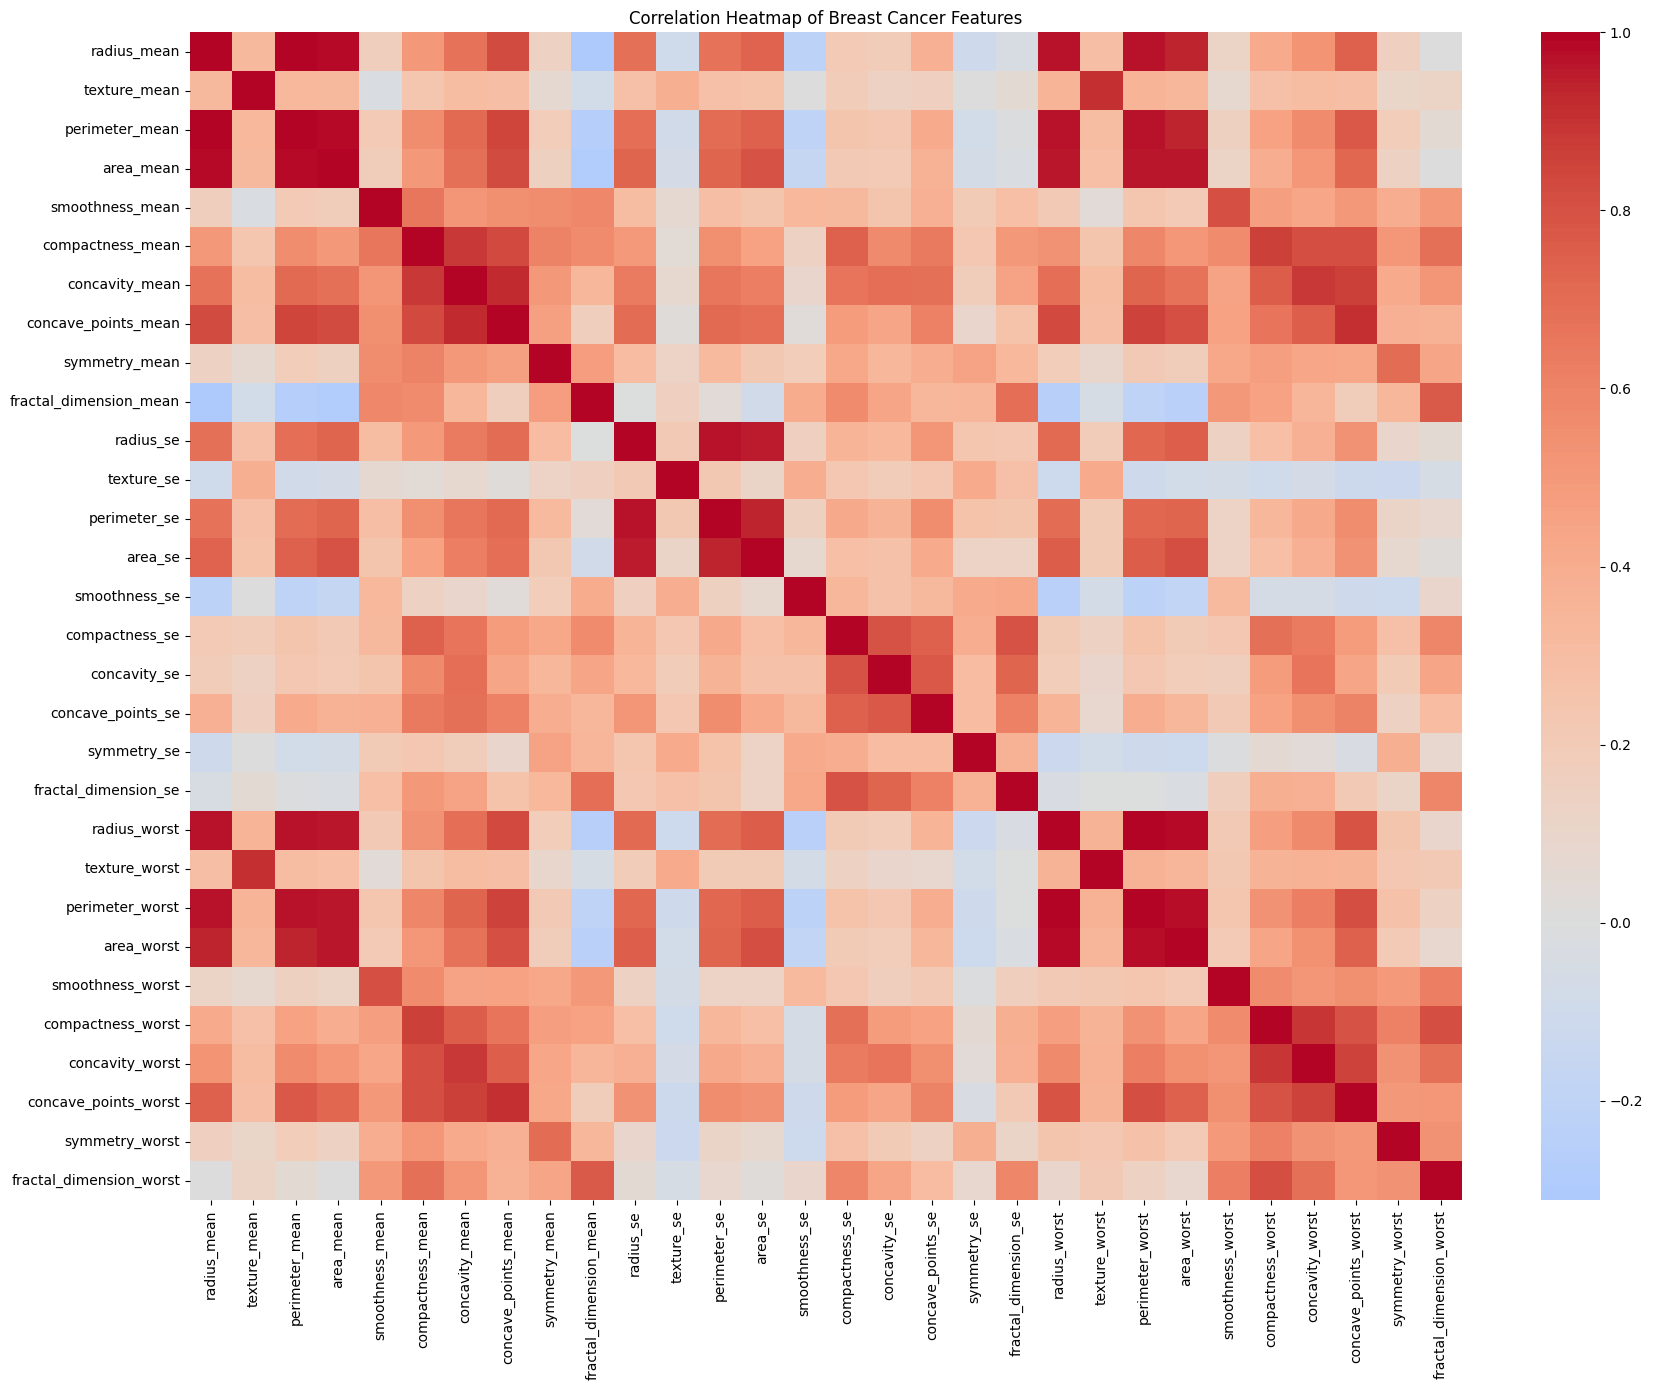

In [15]:
# correlation heatmap

plt.figure(figsize=(18, 14))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Breast Cancer Features")
plt.tight_layout()
plt.show()

In [16]:
# class distribution

print(df["Diagnosis"].value_counts())

Diagnosis
B    357
M    212
Name: count, dtype: int64


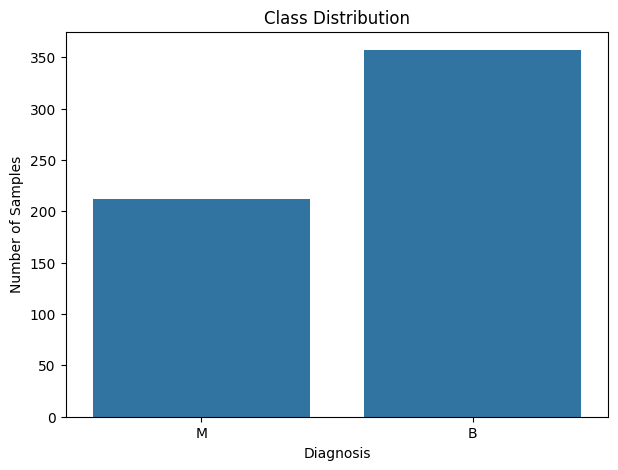

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Diagnosis"
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

In [18]:
class_percentages = df["Diagnosis"].value_counts(normalize=True) * 100

print(class_percentages)

Diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [19]:
# data preprocessing

df["Outcome"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

print(df[["Diagnosis", "Outcome"]].head(10))

  Diagnosis  Outcome
0         M        1
1         M        1
2         M        1
3         M        1
4         M        1
5         M        1
6         M        1
7         M        1
8         M        1
9         M        1


In [20]:
print(df["Outcome"].value_counts())

Outcome
0    357
1    212
Name: count, dtype: int64


In [21]:
X = df.drop(
    columns=["ID", "Diagnosis", "Outcome"]
)

y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [22]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [23]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
Outcome
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [27]:
# standardizing features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [28]:
print("Mean of first 5 standardized features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 standardized features:")
print(X_train_scaled[:, :5].std(axis=0))

Mean of first 5 standardized features:
[-1.73731603e-16  3.90408097e-16  4.70441756e-16 -1.17122429e-16
  7.24207019e-16]

Standard deviation of first 5 standardized features:
[1. 1. 1. 1. 1.]


In [30]:
# model training

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("model trained.")

model trained.


In [31]:
# predictions

y_pred = logistic_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


In [32]:
# accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9649122807017544
Accuracy (%): 96.49122807017544


In [33]:
# precision

precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 0.975


In [34]:
# recall

recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.9285714285714286


In [35]:
# f1 score

f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.9512195121951219


In [37]:
# evaluation for both classes

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [38]:
# confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[71  1]
 [ 3 39]]


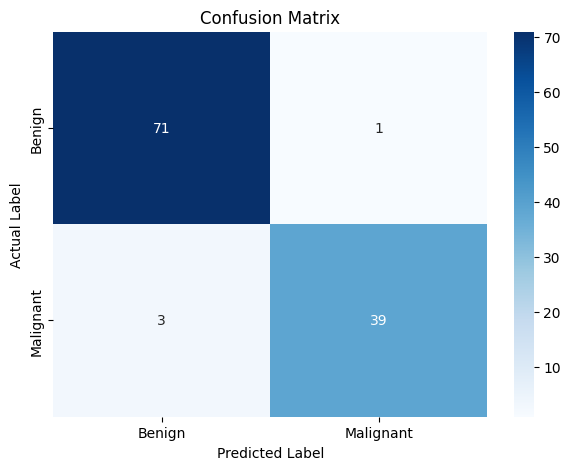

In [39]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [40]:
# ROC curve

y_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print(y_prob[:10])

[3.64568116e-04 9.99999989e-01 4.25679471e-02 5.76187322e-01
 5.09155489e-01 6.16001620e-04 7.61534086e-01 1.01217174e-03
 5.68725516e-04 1.07675795e-02]


In [41]:
# caluculating ROC and AUC

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.996031746031746


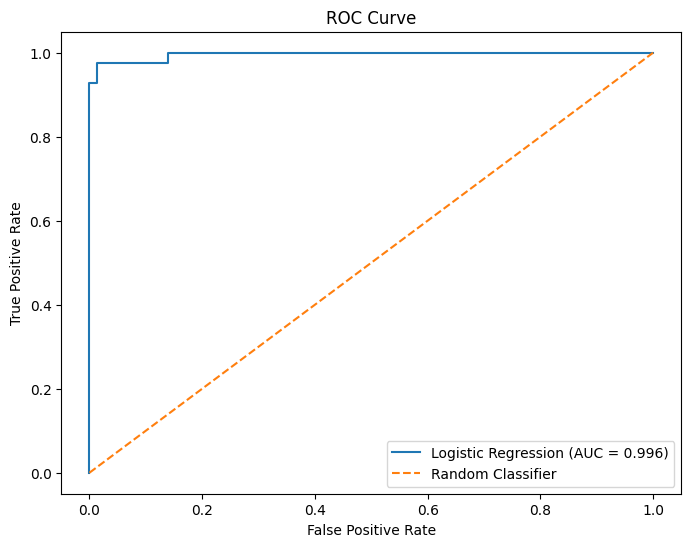

In [42]:
# plotting ROC curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [43]:
# evaluation table

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Malignant)",
        "Recall (Malignant)",
        "F1 Score (Malignant)",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

results

,Metric,Score
0,Accuracy,0.964912
1,Precision (Malignant),0.975000
2,Recall (Malignant),0.928571
3,F1 Score (Malignant),0.951220
4,ROC-AUC,0.996032


In [44]:
# classification report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"],
    output_dict=True
)

report_df = pd.DataFrame(report).T

report_df

,precision,recall,f1-score,support
Benign,0.959459,0.986111,0.972603,72.000000
Malignant,0.975000,0.928571,0.951220,42.000000
accuracy,0.964912,0.964912,0.964912,0.964912
macro avg,0.967230,0.957341,0.961911,114.000000
weighted avg,0.965185,0.964912,0.964725,114.000000


In [45]:
# model summary

print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision (Malignant) : {precision:.4f}")
print(f"Recall (Malignant)    : {recall:.4f}")
print(f"F1 Score (Malignant)  : {f1:.4f}")
print(f"ROC-AUC               : {auc_score:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

Accuracy              : 0.9649
Precision (Malignant) : 0.9750
Recall (Malignant)    : 0.9286
F1 Score (Malignant)  : 0.9512
ROC-AUC               : 0.9960

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

